Saving student_feedbackT3.csv to student_feedbackT3.csv


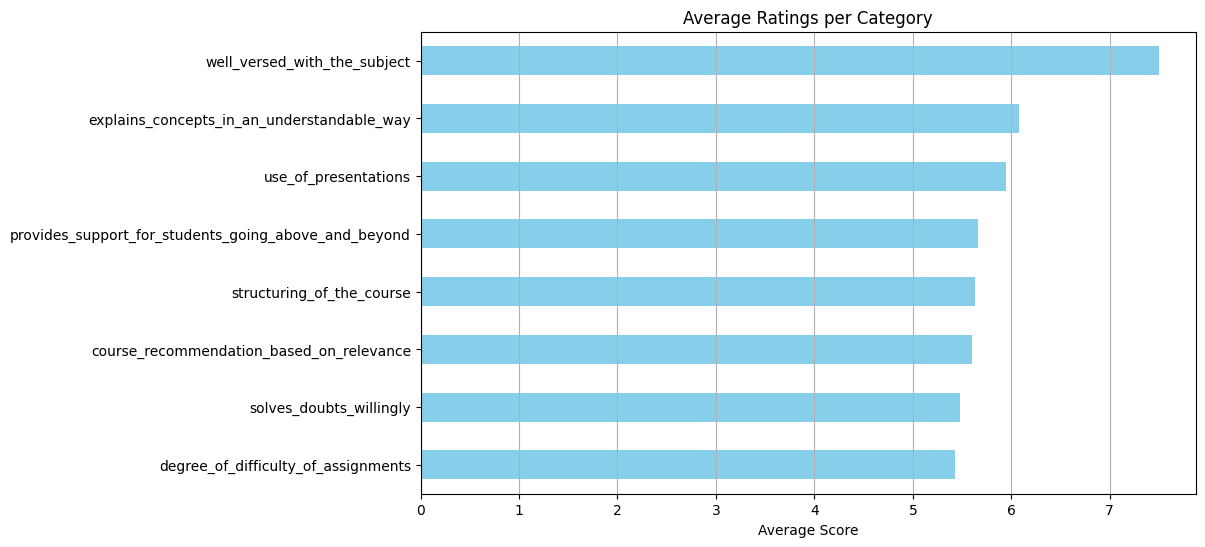

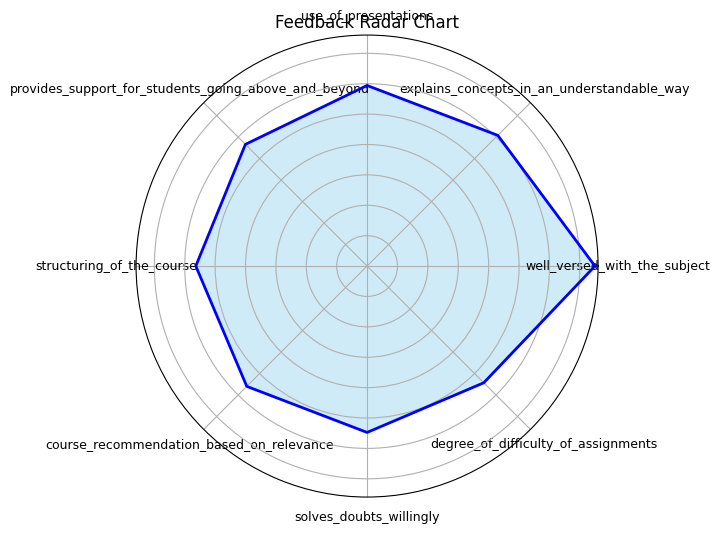

/tmp/ipython-input-4187876801.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


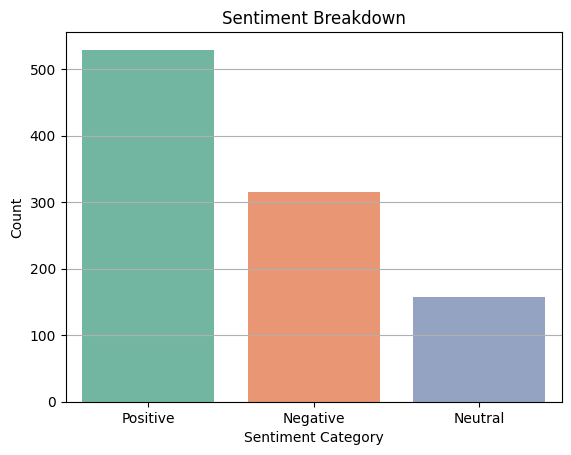

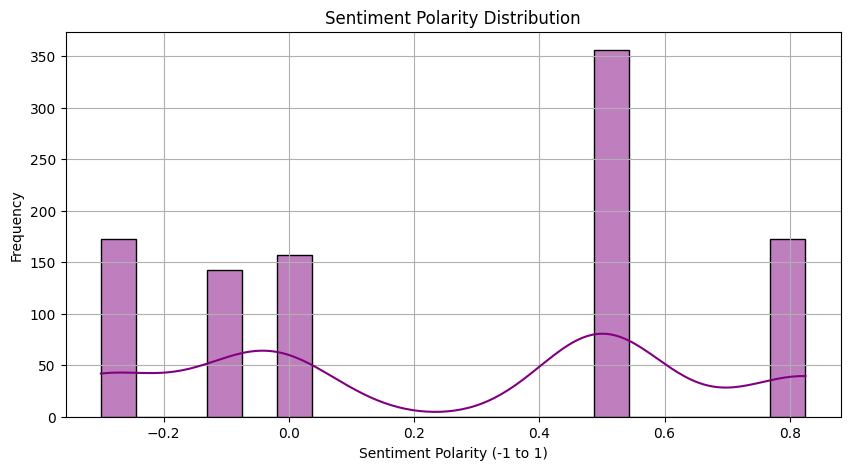

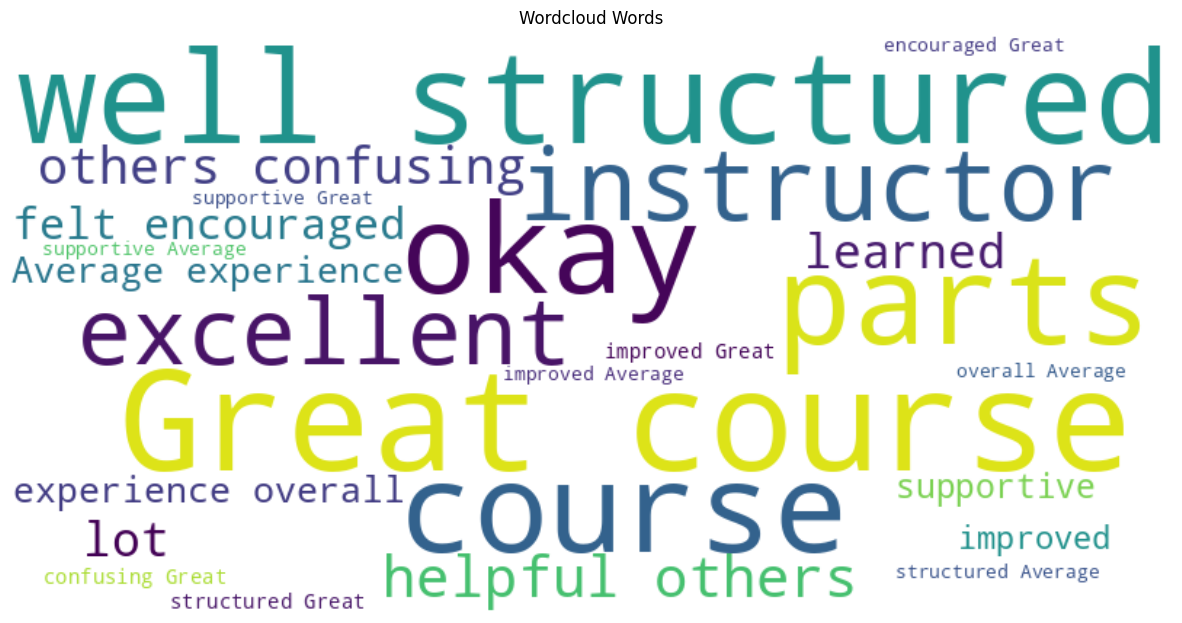

In [1]:
# 📦 Load Data
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from textblob import TextBlob
from wordcloud import WordCloud
import random

# Upload CSV
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ✅ Define rating columns (excluding student_id)
rating_columns = [
    'well_versed_with_the_subject',
    'explains_concepts_in_an_understandable_way',
    'use_of_presentations',
    'provides_support_for_students_going_above_and_beyond',
    'structuring_of_the_course',
    'course_recommendation_based_on_relevance',
    'solves_doubts_willingly',
    'degree_of_difficulty_of_assignments'
]
# 📊 Average Ratings Bar Chart
avg_ratings = df[rating_columns].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_ratings.plot(kind='barh', color='skyblue')
plt.title('Average Ratings per Category')
plt.xlabel('Average Score')
plt.grid(axis='x')
plt.show()

# 📈 Radar Chart
labels = rating_columns
values = df[labels].mean().tolist()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='blue', linewidth=2)
ax.fill(angles, values, color='skyblue', alpha=0.4)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
plt.title('Feedback Radar Chart')
plt.show()
# 💬 Simulate Comments
def generate_comment(rating):
    if rating >= 8:
        return random.choice([
            "The instructor was excellent and very supportive.",
            "Great course, very well structured.",
            "I learned a lot and felt encouraged."
        ])
    elif rating >= 5:
        return random.choice([
            "The course was okay, but could be improved.",
            "Some parts were helpful, others confusing.",
            "Average experience overall."
        ])
    else:
        return random.choice([
            "I struggled with the material and felt unsupported.",
            "The sessions were unclear and disorganized.",
            "Not a good learning experience."
        ])

df['comments'] = df['well_versed_with_the_subject'].apply(generate_comment)

# 🧠 Sentiment Scoring
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['comments'].apply(get_sentiment)

# 📊 Sentiment Breakdown
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Breakdown')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

# 📈 Sentiment Polarity Distribution
df['polarity'] = df['comments'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(10, 5))
sns.histplot(df['polarity'], bins=20, kde=True, color='purple')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Sentiment Polarity (-1 to 1)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# ☁️ Word Cloud
text = ' '.join(df['comments'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud Words")
plt.show()


# New Section